# High-Performance Softmax: A Deep Dive into Kernel Fusion

---

## Workshop Overview

| Topic | Description |
|-------|-------------|
| **Objective** | Build a memory-efficient fused softmax operation |
| **Key Insight** | Kernel fusion eliminates redundant memory traffic |
| **Performance Target** | ~4x speedup over naive implementations |
| **Constraint** | Row dimensions must fit within GPU SRAM |

Notebook is inspired and made based on work from @Twonadorable

---

## Part 1: Understanding the Memory Bottleneck

### The Problem with Naive Approaches

Consider the standard numerically-stable softmax formula:

$$\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}$$

A naive implementation requires **multiple passes** over the data:

1. **Pass 1**: Find maximum (read: MN)
2. **Pass 2**: Subtract max, compute exp (read: MN+M, write: MN)
3. **Pass 3**: Sum exponentials (read: MN)
4. **Pass 4**: Normalize (read: MN+M, write: MN)

> **Memory I/O Analysis**: For an M×N matrix, this totals **5MN + 2M reads** and **3MN + 2M writes**!



In [ ]:
# ============================================================================
# SECTION: Environment Setup & Dependencies
# ============================================================================

import torch
import triton
import triton.language as tl
from triton.runtime import driver

# Acquire the active compute device
DEVICE = triton.runtime.driver.active.get_active_torch_device()

# ============================================================================
# SECTION: Hardware Detection Utilities  
# ============================================================================

def detect_hip_backend():
    """Check if running on AMD HIP backend."""
    return triton.runtime.driver.active.get_current_target().backend == "hip"

def detect_cdna_architecture():
    """Identify AMD CDNA architecture variants."""
    cdna_architectures = ('gfx940', 'gfx941', 'gfx942', 'gfx90a', 'gfx908')
    return detect_hip_backend() and triton.runtime.driver.active.get_current_target().arch in cdna_architectures

# ============================================================================
# SECTION: Baseline Implementation (For Comparison)
# ============================================================================

def baseline_softmax_pytorch(input_tensor):
    """
    Standard PyTorch softmax with numerical stabilization.
    
    This implementation demonstrates the memory inefficiency problem:
    each operation creates intermediate tensors stored in global memory.
    
    Args:
        input_tensor: 2D tensor of shape (M, N)
    
    Returns:
        Row-wise softmax probabilities
    """
    # Operation 1: Extract row-wise maximum values
    # Memory: READ MN elements, WRITE M elements
    row_maxima = input_tensor.max(dim=1)[0]
    
    # Operation 2: Shift inputs for numerical stability  
    # Memory: READ MN + M elements, WRITE MN elements
    shifted_input = input_tensor - row_maxima[:, None]
    
    # Operation 3: Compute element-wise exponentials
    # Memory: READ MN elements, WRITE MN elements
    exp_values = torch.exp(shifted_input)
    
    # Operation 4: Compute normalization factors
    # Memory: READ MN elements, WRITE M elements
    partition_function = exp_values.sum(dim=1)
    
    # Operation 5: Final normalization
    # Memory: READ MN + M elements, WRITE MN elements
    probabilities = exp_values / partition_function[:, None]
    
    return probabilities

---

##  Part 2: The Fused Kernel Solution

### Design Philosophy

```
┌─────────────────────────────────────────────────────────────┐
│                    KERNEL FUSION STRATEGY                    │
├─────────────────────────────────────────────────────────────┤
│  ✓ Load entire row into SRAM once                           │
│  ✓ Perform all computations on-chip                         │
│  ✓ Write final result back to DRAM once                     │
│  ✓ Theoretical I/O: 2MN (vs 8MN + 4M naive)                 │
└─────────────────────────────────────────────────────────────┘
```

### Implementation Considerations

- **Power-of-two constraint**: Triton blocks require 2^k elements
- **Masking strategy**: Handle irregular column counts gracefully
- **Persistent threads**: Process multiple rows per program instance



### Triton Kernel Implementation

The kernel operates on a **per-row basis** with strided access patterns. Each program instance:
1. Loads assigned rows into registers
2. Executes the complete softmax pipeline on-chip
3. Writes normalized results back to global memory



In [ ]:
# ============================================================================
# SECTION: Triton Fused Softmax Kernel
# ============================================================================

@triton.jit
def fused_softmax_forward(
    # Tensor pointers
    output_ptr, input_ptr,
    # Stride information
    input_row_stride, output_row_stride,
    # Dimensions
    n_rows, n_cols,
    # Compile-time constants
    BLOCK_SIZE: tl.constexpr,
    num_stages: tl.constexpr
):
    """
    Fused row-wise softmax kernel.
    
    Each program instance processes rows in a strided pattern,
    loading complete rows into SRAM for on-chip computation.
    """
    # Determine which rows this program instance handles
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    
    # Process assigned rows with software pipelining
    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):
        # Calculate base pointer for current row
        row_start_ptr = input_ptr + row_idx * input_row_stride
        
        # Generate column indices [0, 1, 2, ..., BLOCK_SIZE-1]
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        
        # Create validity mask for out-of-bounds protection
        mask = col_offsets < n_cols
        
        # Load row data (pad with -inf for masked positions)
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
        
        # === SOFTMAX COMPUTATION (entirely on-chip) ===
        # Step 1: Numerical stabilization via max subtraction
        row_minus_max = row - tl.max(row, axis=0)
        
        # Step 2: Fast approximate exponential  
        numerator = tl.exp(row_minus_max)
        
        # Step 3: Compute partition function (sum of exps)
        denominator = tl.sum(numerator, axis=0)
        
        # Step 4: Normalize to get probabilities
        softmax_output = numerator / denominator
        
        # Store results back to global memory
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)

---

##  Part 3: Kernel Launch Configuration

### Occupancy Optimization Strategy

The wrapper function handles critical setup:
- **Block size selection**: Next power-of-two ≥ column count
- **Warp allocation**: Heuristics based on row width
- **Occupancy calculation**: Maximize concurrent wavefronts
- **Architecture-specific tuning**: CDNA vs other backends



In [ ]:
# ============================================================================
# SECTION: Hardware Properties & Kernel Cache
# ============================================================================

# Query device capabilities once at module load
_device_props = driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = _device_props["multiprocessor_count"]
NUM_REGS = _device_props["max_num_regs"]
SIZE_SMEM = _device_props["max_shared_mem"]
WARP_SIZE = _device_props["warpSize"]
_target = triton.runtime.driver.active.get_current_target()

# Kernel compilation cache (avoid redundant JIT)
_kernel_cache = {}

# ============================================================================
# SECTION: High-Level Softmax Interface
# ============================================================================

def triton_softmax(input_matrix):
    """
    Compute row-wise softmax using fused Triton kernel.
    
    Automatically configures launch parameters for optimal
    occupancy based on input dimensions and hardware.
    
    Args:
        input_matrix: 2D tensor of shape (M, N)
    
    Returns:
        Softmax probabilities with same shape as input
    """
    n_rows, n_cols = input_matrix.shape
    
    # Determine block size (must be power of 2 >= n_cols)
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    
    # Warp count heuristic: 8 warps works well in practice
    num_warps = 8
    
    # Pipeline depth depends on available shared memory
    num_stages = 4 if SIZE_SMEM > 200000 else 2
    
    # Prepare output buffer
    output_matrix = torch.empty_like(input_matrix)
    
    # Pre-compile kernel to analyze resource usage
    compiled_kernel = fused_softmax_forward.warmup(
        output_matrix, input_matrix,
        input_matrix.stride(0), output_matrix.stride(0),
        n_rows, n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
        num_stages=num_stages,
        num_warps=num_warps,
        grid=(1,)
    )
    compiled_kernel._init_handles()
    
    # Extract resource consumption metrics
    n_regs = compiled_kernel.n_regs
    size_smem = compiled_kernel.metadata.shared
    
    # Calculate theoretical occupancy
    if detect_hip_backend():
        # AMD CDNA-specific: account for accumulation registers
        # Reference: ISA Section 3.6.4 for CDNA3
        NUM_GPRS = NUM_REGS * 2 if detect_cdna_architecture() else NUM_REGS
        MAX_NUM_THREADS = _device_props["max_threads_per_sm"]
        max_num_waves = MAX_NUM_THREADS // WARP_SIZE
        occupancy = min(NUM_GPRS // WARP_SIZE // n_regs, max_num_waves) // num_warps
    else:
        occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
    
    # Also limit by shared memory availability
    occupancy = min(occupancy, SIZE_SMEM // size_smem)
    
    # Calculate grid size (persistent threads pattern)
    num_programs = min(NUM_SM * occupancy, n_rows)
    
    # Launch the kernel
    compiled_kernel[(num_programs, 1, 1)](
        output_matrix, input_matrix,
        input_matrix.stride(0), output_matrix.stride(0),
        n_rows, n_cols,
        BLOCK_SIZE, num_stages
    )
    
    return output_matrix

---

##  Part 4: Validation Suite

Testing with **irregular dimensions** (1823 × 781) to verify:
- Correct handling of non-power-of-2 column counts
- Proper masking behavior
- Numerical equivalence with PyTorch reference



### Execute Correctness Check



In [ ]:
# ============================================================================
# SECTION: Correctness Verification
# ============================================================================

torch.manual_seed(0)  # Reproducibility

# Create test tensor with deliberately awkward dimensions
test_input = torch.randn(1823, 781, device=DEVICE)

# Compute with both implementations
result_triton = triton_softmax(test_input)
result_pytorch = torch.softmax(test_input, axis=1)

# Verify numerical equivalence
assert torch.allclose(result_triton, result_pytorch), (
    f"Mismatch detected!\nTriton: {result_triton}\nPyTorch: {result_pytorch}"
)

print("✓ Validation PASSED: Triton output matches PyTorch reference")

---

## Part 5: Performance Analysis

### Benchmark Configuration

| Parameter | Value |
|-----------|-------|
| **Rows (M)** | 4096 (fixed) |
| **Columns (N)** | 256 → 12,672 (sweep) |
| **Metric** | Memory throughput (GB/s) |
| **Comparison** | Triton vs PyTorch vs Naive |



### Run Performance Benchmark



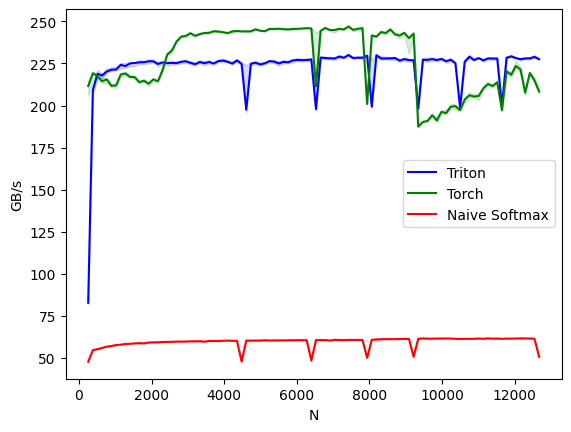

softmax-performance:
          N      Triton       Torch  Naive Softmax
0     256.0   82.799750  211.577077      47.710255
1     384.0  209.157447  219.183942      54.639895
2     512.0  218.726733  217.366503      55.202737
3     640.0  217.872334  214.415181      55.956285
4     768.0  220.227390  215.578943      56.716573
5     896.0  221.245230  211.650280      57.072902
6    1024.0  221.405396  211.983420      57.674276
7    1152.0  224.139853  218.412890      57.862757
8    1280.0  223.443575  219.037436      58.287901
9    1408.0  225.033865  216.973963      58.372144
10   1536.0  225.274138  216.901885      58.653939
11   1664.0  225.627112  213.847386      58.772629
12   1792.0  225.736014  214.746399      58.633947
13   1920.0  226.259280  212.940545      59.135558
14   2048.0  226.278814  215.523556      59.254971
15   2176.0  224.675978  214.396609      59.277831
16   2304.0  225.597246  221.032045      59.458064
17   2432.0  225.199439  230.248512      59.513400
18   2560.

In [ ]:
# ============================================================================
# SECTION: Performance Benchmarking
# ============================================================================

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(2, 100)],
        line_arg='provider',
        line_vals=['triton', 'torch', 'naive_softmax'],
        line_names=["Triton", "Torch", "Naive Softmax"],
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],
        ylabel="GB/s",
        plot_name="softmax-performance",
        args={'M': 4096},
    )
)
def run_benchmark(M, N, provider):
    """
    Benchmark softmax implementations across different column counts.
    
    Returns effective memory bandwidth in GB/s.
    """
    # Prepare input data
    input_data = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    
    # Get appropriate stream for device
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    
    quantiles = [0.5, 0.2, 0.8]
    
    # Select implementation to benchmark
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch.softmax(input_data, axis=-1),
            quantiles=quantiles
        )
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: triton_softmax(input_data),
            quantiles=quantiles
        )
    if provider == 'naive_softmax':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: baseline_softmax_pytorch(input_data),
            quantiles=quantiles
        )
    
    # Calculate effective bandwidth (read + write = 2x elements)
    def compute_bandwidth(ms):
        bytes_transferred = 2 * input_data.numel() * input_data.element_size()
        return bytes_transferred * 1e-9 / (ms * 1e-3)
    
    return compute_bandwidth(ms), compute_bandwidth(max_ms), compute_bandwidth(min_ms)

# Execute benchmark and export results
benchmark_results = run_benchmark.run(show_plots=True, print_data=True, return_df=True)
benchmark_results.to_csv('softmax_performance.csv')

---

##  Key Takeaways

### Performance Results Summary

| Implementation | Relative Performance |
|----------------|---------------------|
| **Triton (fused)** |   Best for small-to-medium N |
| **PyTorch native** | Competitive, more general |
| **Naive (unfused)** | ~4x slower due to memory I/O |

### Why Triton Wins

1. **Kernel Fusion**: Single-pass computation eliminates intermediate memory traffic
2. **Register Blocking**: Data stays in fast register file during computation
3. **Occupancy Tuning**: Automatic adjustment to maximize GPU utilization

### Limitations

- Row size must fit in SRAM (typically ≤ 64KB)
- PyTorch's `softmax` is more flexible for arbitrary tensor shapes
- For very large N, multi-block reduction strategies are needed

---

*Workshop complete. For production use, consider auto-tuning kernel parameters.*

